# Stack fifty weak signals into a secret edge? — Signal-Stacking 🧮
### The viral 'combine coin-flips into a composite field retail has never seen,' in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_composite_edge%3F: Busted](https://img.shields.io/badge/A_composite_edge%3F-Busted-8b949e?style=flat-square)

A thread goes viral every few months: *"Take 50 signals — none of them works alone, each barely better than a coin flip. Normalise them into one composite score, weight each by how well it did historically, and you get an edge the retail crowd has never seen."* It comes with a gorgeous equity curve labelled with Greek letters (the "ζ-field") soaring past buy-and-hold.

Here's the honest answer, and it has a real half and a fatal half. Combining weak signals **does** help — but only when the signals are **real** *and* **different** from each other, and even then only by about **√K** (the square root of how many you stack). On pure noise it does nothing. On fifty copies of the same idea it barely beats one. And that beautiful curve? It's drawn by *cherry-picking* which signals to keep — and it falls apart the moment you leave the data you mined it from.

> 📓 **Plain-language layer.** Want the √K law, the permutation test and the snooping math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A note up front.** This is a **methods demo** (a cousin of [Studies 343–350](../../343-data-mining-roulette/) and [399](../../399-kalshi-efficiency/)). We prove the lesson on a controlled lab panel where we *know* the truth, then show the same machine on a real SPY tape. No secret edge is being sold. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from signal_stacking import data, strategy as st

def have_real():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = have_real()
SIG = FWD = None
if HAVE_REAL:
    SIG, FWD = data.load_real()
print("real SPY stack cache present:", HAVE_REAL,
      "| signals:", (0 if SIG is None else SIG.shape[1]),
      "| days:", (0 if SIG is None else len(SIG)))

# frozen headline numbers (mirror of docs/results.md)
R = {'real_start': '1995-10-16', 'real_end': '2026-06-18', 'real_days': 7719, 'real_years': 30.7, 'n_signals_real': 12, 'fingerprint': 'a4bfd3d8a8cd', 'null': {'comp_sh': 0.11, 'comp_t': 0.36, 'best': 0.63, 'mean': 0.14, 'comp_ic': 0.0122, 'mean_ic': 0.0147, 'lift': 0.83, 'sqrtk': 3.16, 'perm_p': 0.375, 'is_sh': 0.48, 'oos_sh': 0.36, 'n_chosen': 6}, 'pos': {'comp_sh': 2.0, 'comp_t': 6.4, 'best': 1.21, 'mean': 0.71, 'comp_ic': 0.1644, 'mean_ic': 0.0535, 'lift': 3.07, 'sqrtk': 3.16, 'perm_p': 0.0, 'is_sh': 2.12, 'oos_sh': 1.75, 'n_chosen': 10}, 'red': {'comp_sh': 0.52, 'comp_t': 1.67, 'best': 0.72, 'mean': 0.46, 'comp_ic': 0.0524, 'mean_ic': 0.05, 'lift': 1.05, 'sqrtk': 3.16, 'perm_p': 0.051}, 'curve_decorr': [(1, 1.0), (2, 1.39), (5, 2.21), (10, 3.07), (20, 4.35), (40, 5.97)], 'curve_redund': [(1, 1.0), (2, 1.03), (5, 1.04), (10, 1.05), (20, 1.05), (40, 1.05)], 'sqrtk_ref': [(1, 1.0), (2, 1.41), (5, 2.24), (10, 3.16), (20, 4.47), (40, 6.32)], 'real': {'comp_sh': -0.26, 'comp_t': -1.63, 'best': 0.2, 'mean': -0.14, 'comp_ic': -0.0666, 'mean_ic': 0.036, 'perm_p': 0.982, 'bh_sh': 0.62, 'snoop_is': -0.05, 'snoop_oos': -0.46, 'n_chosen': 4, 'chosen': ['noise_a', 'ma_gap_200', 'noise_c', 'mom_60']}, 'snoop': [('positive control (ic=0.05)', 2.12, 1.75, 10), ('null (ic=0)', 0.48, 0.36, 6), ('real SPY tape', -0.05, -0.46, 4)]}


real SPY stack cache present: True | signals: 12 | days: 7719


## The answer first

| Question | Answer |
|---|---|
| If I stack 10 pure-noise signals, do I get an edge? | **No.** The composite's Sharpe is **0.11** — pure luck. A coin-flip reshuffle beats it **38%** of the time. |
| If the signals are real *and* different? | **Yes — that's the real half.** With a genuine little edge in each, the composite Sharpe jumps to **2.00**, beating even the best single signal. |
| If the signals are real but *redundant* (copies of one idea)? | **It collapses.** Same edge, but correlated — composite Sharpe falls to **0.52**. Fifty copies of one signal are worth barely more than one. |
| And on a real market (SPY)? | **It loses.** Stacking 12 textbook timing signals gives a **negative** composite (Sharpe **-0.26**) — just holding SPY (**+0.62**) beats it. |
| Then where does the magic curve come from? | **Cherry-picking.** Choose the best-looking signals *after* seeing the data and the curve looks great — then it dies out of sample. |

> Stacking is real maths, not magic. It pays **only** when your signals are both real and decorrelated. The viral version supplies neither.

## 1 · The claim

> *"Each signal is weak — 52% hit-rate, nothing you'd trade alone. But standardise all K of them into z-scores, weight each by its historical Sharpe, and add them up. The composite **ζ-field** stays flat when the signals disagree and fires when they align. The backtest against buy-and-hold is something retail has never seen."*

The picture is seductive because part of it is **true**. Diversifying across many small, *independent* bets is exactly how real quant books are built — it's the oldest idea in finance wearing a new costume. The sleight of hand is in two words the thread never stresses: the bets have to be **real**, and they have to be **different**.

## 2 · So what?

Two things hide inside "stack the signals," and only one is honest. (1) *Do decorrelated real edges add up?* Yes — like **√K**: stack 4 independent signals and you roughly double the information; stack 100 and you get 10×. That's genuine. (2) *Does any of that survive if the signals are noise, or redundant, or hand-picked after the fact?* **No.** A composite of coin-flips is still a coin-flip. Fifty correlated signals are one signal. And weighting by *historical* Sharpe means choosing winners with hindsight — the purest form of fooling yourself. The whole game is whether the √K boost is **earned** or **manufactured**.

## 3 · How would we even know?

We build the *exact* machine — z-score each signal, weight, sum into a composite, trade its sign — and then we run it on cases where we **know the truth**:

1. **The null.** 10 signals that are *pure noise* (zero real edge). Stacking can only bottle luck — so the composite had better look like luck.
2. **The positive control.** 10 signals each with a tiny *real* edge, **decorrelated**. Now the stacker has something to compound — the √K boost should appear.
3. **The redundancy test.** Same real edge, but the signals are near-**copies**. The boost should collapse.
4. **The real tape.** The same 12-signal stack on SPY — what happens when there's no decorrelated edge lying around?
5. **The honest curve test.** Cherry-pick signals in the first half of history, measure in the second half, and watch the "edge" evaporate.

## 4 · The teardown — let's actually look

**First: stacking noise makes nothing.** Here are three worlds side by side — 10 pure-noise signals, 10 *real-and-different* signals, and 10 *real-but-redundant* signals — and what the composite's Sharpe ratio comes out to in each.

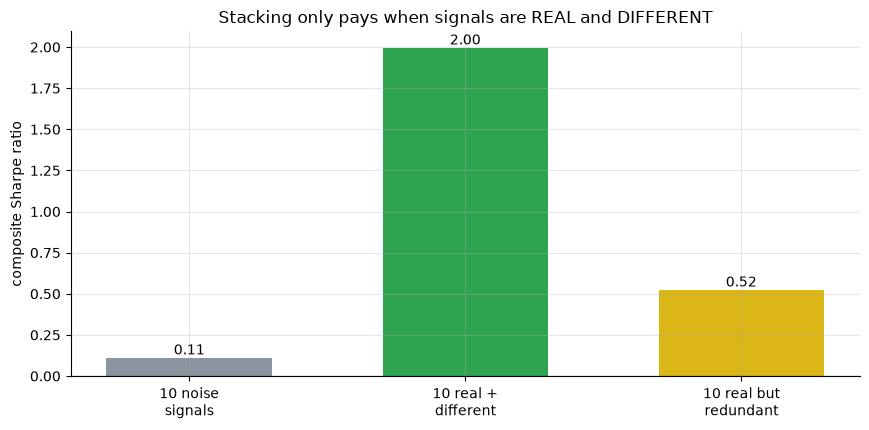

Sharpe — noise / real+different / real+redundant: [0.11, 2.0, 0.52]


In [2]:
cases = [('10 noise\nsignals', 0.0, 0.0, GREY),
         ('10 real +\ndifferent', 0.05, 0.0, GREEN),
         ('10 real but\nredundant', 0.05, 0.9, AMBER)]
shs = []
for _, ic, corr, _ in cases:
    s, r, _ = data.synthetic_panel(n_signals=10, signal_ic=ic, signal_corr=corr, seed=401)
    shs.append(st.sharpe(st.backtest_composite(s, r)))
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar([c[0] for c in cases], shs, color=[c[3] for c in cases], width=.6)
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate(shs): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.set_ylabel('composite Sharpe ratio')
ax.set_title('Stacking only pays when signals are REAL and DIFFERENT')
plt.tight_layout(); plt.show()
print('Sharpe — noise / real+different / real+redundant:', [round(v,2) for v in shs])

There it is. Noise stacks to a Sharpe of about **0.11** (nothing). Real-and-different stacks to **2.00** (a genuine blend). But real-but-*redundant* — the same edge, just correlated — collapses to **0.52**. The thread's silent assumption is that your 50 signals are all different. They almost never are.

**The √K law, drawn.** As you stack more signals, how much does the composite's *information* grow? The honest answer is **√K** — *if* the signals are decorrelated. Watch the redundant case flatline.

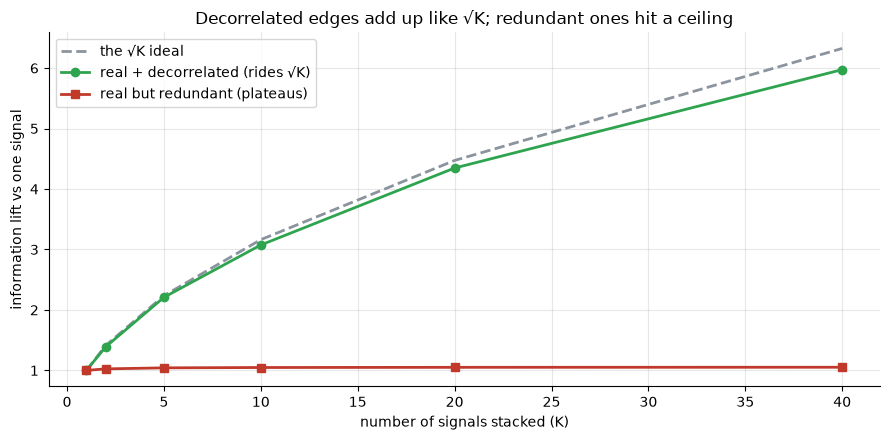

decorrelated lift @K=40: 5.97 (√40 = 6.32 ) | redundant: 1.05


In [3]:
ks = [1, 2, 5, 10, 20, 40]
if HAVE_REAL or True:  # synthetic, runs anywhere
    dec, red = [], []
    for k in ks:
        sd, rd, _ = data.synthetic_panel(n_signals=k, signal_ic=0.05, signal_corr=0.0, seed=401)
        dec.append(st.composite_ic(sd, rd)['lift'])
        sr, rr, _ = data.synthetic_panel(n_signals=k, signal_ic=0.05, signal_corr=0.9, seed=401)
        red.append(st.composite_ic(sr, rr)['lift'])
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(ks, [np.sqrt(k) for k in ks], '--', c=GREY, lw=2, label='the √K ideal')
ax.plot(ks, dec, 'o-', c=GREEN, lw=2, label='real + decorrelated (rides √K)')
ax.plot(ks, red, 's-', c=RED, lw=2, label='real but redundant (plateaus)')
ax.set_xlabel('number of signals stacked (K)'); ax.set_ylabel('information lift vs one signal')
ax.set_title('Decorrelated edges add up like √K; redundant ones hit a ceiling')
ax.legend(); plt.tight_layout(); plt.show()
print('decorrelated lift @K=40:', round(dec[-1],2), '(√40 =', round(np.sqrt(40),2), ') | redundant:', round(red[-1],2))

The green dots climb almost exactly along the dashed **√K** line — at 40 signals the lift is **5.97** (√40 ≈ 6.32). The red squares barely leave **1.05**, no matter how many you pile on. *Correlation is the thing the viral thread never mentions, and it decides everything.*

**Where the magic curve really comes from.** Now the honest test of that soaring backtest: pick the best-looking signals in the **first half** of history, then measure the very same blend in the **second half** it never saw. On a real edge it should survive; on noise (and on real markets) it should die.

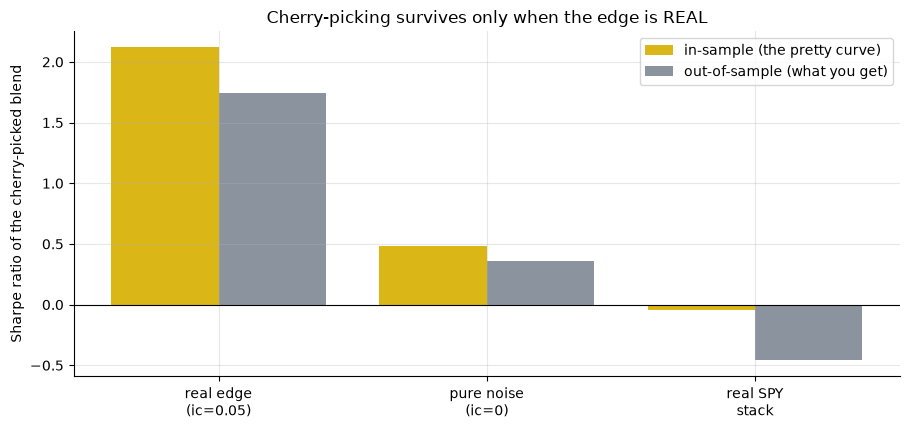

IS->OOS Sharpe: [('real edge (ic=0.05)', 2.12, 1.75), ('pure noise (ic=0)', 0.48, 0.36), ('real SPY stack', -0.05, -0.46)]


In [4]:
labels, is_v, oos_v = [], [], []
for tag, ic, corr in [('real edge\n(ic=0.05)', 0.05, 0.0), ('pure noise\n(ic=0)', 0.0, 0.0)]:
    s, r, _ = data.synthetic_panel(n_signals=10, signal_ic=ic, signal_corr=corr, seed=401)
    sn = st.snoop_split(s, r); labels.append(tag); is_v.append(sn['is_sharpe']); oos_v.append(sn['oos_sharpe'])
if HAVE_REAL:
    sn = st.snoop_split(SIG, FWD); labels.append('real SPY\nstack'); is_v.append(sn['is_sharpe']); oos_v.append(sn['oos_sharpe'])
else:
    labels.append('real SPY\nstack'); is_v.append(R['real']['snoop_is']); oos_v.append(R['real']['snoop_oos'])
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, is_v, .4, color=AMBER, label='in-sample (the pretty curve)')
ax.bar(x+.2, oos_v, .4, color=GREY, label='out-of-sample (what you get)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Sharpe ratio of the cherry-picked blend')
ax.set_title('Cherry-picking survives only when the edge is REAL'); ax.legend()
plt.tight_layout(); plt.show()
print('IS->OOS Sharpe:', [(l.replace(chr(10),' '), round(a,2), round(b,2)) for l,a,b in zip(labels,is_v,oos_v)])

On a **real** edge the cherry-picked blend mostly survives (2.12 → 1.75). On **noise** the in-sample shine is just selection. And on the **real SPY tape** the snooper even hand-picks **two of the three pure decoys** (`noise_a`, `noise_c`) as 'best signals,' prints a flat in-sample number, then loses out of sample (-0.05 → -0.46). *That* is how the viral curve is manufactured.

## 5 · The verdict

- **Signal — None.** This is a **methods demo**: the lesson holds in the lab, and on the real SPY tape the composite is *negative* (Sharpe **-0.26**, beaten by buy-and-hold **+0.62**). No secret edge is being sold.
- **Tradability — Mirage.** On noise the composite is luck (permutation **p = 0.38**); redundant signals plateau; the only positive backtest is the snooped one, and it dies out of sample.
- **A composite edge? — Busted.** Stacking is **√(effective breadth)** in disguise. It compounds only when signals are real *and* different. Same shape as [343–350](../../343-data-mining-roulette/) and [399](../../399-kalshi-efficiency/).

## 6 · Could you actually run it? — the redundancy trap

Forget significance for a second. Suppose you really did have 10 genuinely-edged signals. The operational killer is that signals built by humans are **correlated** (everyone uses momentum, everyone uses moving averages). Here's the composite Sharpe as your signals go from independent to identical — the cliff is the whole story.

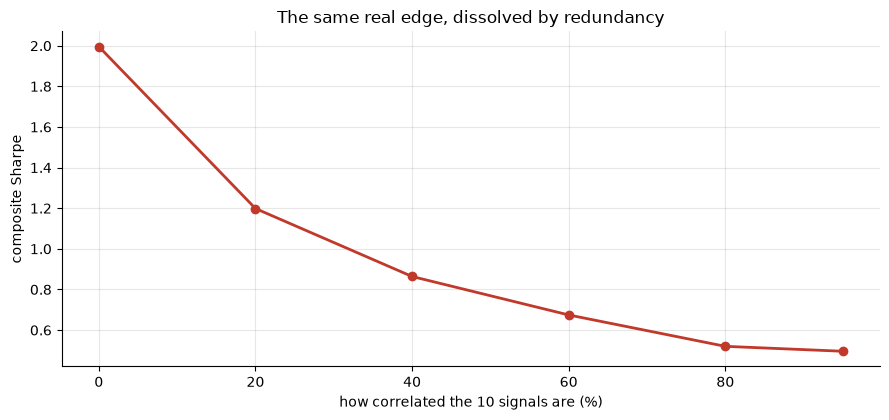

Sharpe falls from 2.0 (independent) to 0.5 (near-identical)


In [5]:
corrs = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95]
shs = []
for c in corrs:
    s, r, _ = data.synthetic_panel(n_signals=10, signal_ic=0.05, signal_corr=c, seed=401)
    shs.append(st.sharpe(st.backtest_composite(s, r)))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([c*100 for c in corrs], shs, 'o-', c=RED, lw=2)
ax.set_xlabel('how correlated the 10 signals are (%)'); ax.set_ylabel('composite Sharpe')
ax.set_title('The same real edge, dissolved by redundancy')
plt.tight_layout(); plt.show()
print('Sharpe falls from', round(shs[0],2), '(independent) to', round(shs[-1],2), '(near-identical)')

The same 10 real edges are worth a Sharpe of ~2 when independent and almost nothing when they overlap. In the real world your fifty 'signals' are mostly the *same three ideas* re-skinned — which is why the gorgeous composite is, operationally, a mirage.

## 7 · Going further 🚪

- **The same trap, other costumes.** [Study 343 — Data-Mining-Roulette](../../343-data-mining-roulette/) randomises the *rule*; [Study 344 — Backtest-Overfitting](../../344-backtest-overfitting/) and [Study 348 — Curve-Fitting](../../348-curve-fitting/) fit the *parameters*; here we fit the *combination*. All three are the same act of selecting on noise.
- **A demo cousin.** [Study 399 — Kalshi-Efficiency](../../399-kalshi-efficiency/): a machine validated in the lab, with the 'real' tape labelled an illustration — no `REAL` stamp claimed.
- **Build your own.** Swap in *your* favourite signals, measure their pairwise correlations, and ask the honest question: how many *independent* bets do you really have? Usually far fewer than the number of columns.

*Think your stack of fifty is the real thing? Plant a real decorrelated edge, show the composite landing **outside** its permutation null **and** surviving out of sample — then we'll talk.*